# **Importing Libraries and Describing Dataset**

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('credit_card_fraud.csv')

In [ ]:
# Display the first few rows of the DataFrame
print("DataFrame Head:")
print(df.head())

DataFrame Head:
  Transaction Date and Time  Transaction Amount        Cardholder Name  \
0       2022-09-24 13:54:27              285.88            Shray Soman   
1       2020-07-24 11:20:13             1777.32         Lakshit Bakshi   
2       2023-03-18 01:05:36             3939.01             Riya Bobal   
3       2021-01-07 21:53:04              376.44  Mohanlal Balakrishnan   
4       2021-12-16 06:22:24             1687.33            Mannat Rout   

                   Card Number (Hashed or Encrypted)  \
0  daca51bffe0fc4eaaa7c430917f94b75fd893712492254...   
1  d5366dd9be3a0266c0252baceaa6332210ed4dbd0ef252...   
2  4737a6384aa1c3c31f7768b86633d6a8401dd6ab4a8ff1...   
3  4721806eed8f2663bb597ff13e79a294de318358fbb54b...   
4  9deacc3a9efd6e382826d400620aca5f23ed94327578e5...   

                 Merchant Name  Merchant Category Code (MCC)  \
0  Rajagopalan, Ghose and Kant                          3590   
1                     Sule PLC                          7277   
2         

In [ ]:
# Print the shape of the DataFrame
print("\nDataFrame Shape:")
print(df.shape)


DataFrame Shape:
(8000, 20)


In [ ]:
# Print a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Transaction Date and Time                8000 non-null   object 
 1   Transaction Amount                       8000 non-null   float64
 2   Cardholder Name                          8000 non-null   object 
 3   Card Number (Hashed or Encrypted)        8000 non-null   object 
 4   Merchant Name                            8000 non-null   object 
 5   Merchant Category Code (MCC)             8000 non-null   int64  
 6   Transaction Location (City or ZIP Code)  8000 non-null   object 
 7   Transaction Currency                     8000 non-null   object 
 8   Card Type                                8000 non-null   object 
 9   Card Expiration Date                     8000 non-null   object 
 10  CVV Code (Hashed or Encrypted) 

In [ ]:
# Generate descriptive statistics for the numerical columns of the DataFrame
print("\nDataFrame Descriptive Statistics:")
print(df.describe())


DataFrame Descriptive Statistics:
       Transaction Amount  Merchant Category Code (MCC)  \
count         8000.000000                   8000.000000   
mean          2496.356036                   5484.150375   
std           1451.221326                   2608.164617   
min              1.090000                   1000.000000   
25%           1242.580000                   3230.750000   
50%           2492.460000                   5455.000000   
75%           3739.522500                   7761.000000   
max           4996.700000                   9999.000000   

       Transaction Response Code  Fraud Flag or Label  
count                8000.000000          8000.000000  
mean                    5.637500             0.498625  
std                     4.928147             0.500029  
min                     0.000000             0.000000  
25%                     0.000000             0.000000  
50%                     5.000000             0.000000  
75%                    12.000000         

## **Dataset Overview**

The dataset contains **8000 rows** and **20 columns**, providing a detailed record of credit card transactions.

#### Data Types and Missing Values:

- There are **1 float64** column (`Transaction Amount`), **3 int64** columns (`Merchant Category Code (MCC)`, `Transaction Response Code`, `Fraud Flag or Label`), and **16 object** columns (the rest).
- Two columns have **missing values**:
    - `Previous Transactions`: 2043 missing values (8000 - 5957 non-null entries).
    - `User Account Information`: 4010 missing values (8000 - 3990 non-null entries).

#### Descriptive Statistics for Numerical Columns:

- **Transaction Amount**: Ranges from 1.09 to 4996.70, with a mean of approximately 2496.36, indicating a wide range of transaction values.
- **Merchant Category Code (MCC)**: Ranges from 1000 to 9999, with a mean of around 5484.15.
- **Transaction Response Code**: Ranges from 0 to 12, with a mean of about 5.64.
- **Fraud Flag or Label**: This is a binary flag (0 or 1), with a mean of approximately 0.4986, suggesting a nearly balanced distribution of fraudulent and non-fraudulent transactions in the dataset.

# **Identify Potential Features for ML**

Analyze the dataset's columns to identify which variables are suitable as features for machine learning models, considering their relevance to the 'Fraud Flag or Label' target. This will involve distinguishing between numerical, categorical, and potentially complex features (e.g., date/time, hashed IDs, text) that may require specific preprocessing.



Based on the previous `df.info()` and `df.head()` outputs, we will categorize the columns into numerical and categorical, and those to be dropped or requiring advanced preprocessing. This categorization is essential for feature selection in machine learning, ensuring that the target variable is excluded and appropriate features are identified for model training.



In [ ]:
target_variable = 'Fraud Flag or Label'

numerical_features = [
    'Transaction Amount'
]

categorical_features = [
    'Merchant Category Code (MCC)', # Although int, it's a code, likely categorical
    'Transaction Currency',
    'Card Type',
    'Transaction Response Code', # Although int, it's a code, likely categorical
    'Previous Transactions',
    'Transaction Source',
    'Device Information'
]

# Features that are identifiers, free text, hashed, or require complex preprocessing
features_to_drop = [
    'Transaction Date and Time', # Datetime, requires feature engineering
    'Cardholder Name',           # High cardinality, PII
    'Card Number (Hashed or Encrypted)', # Hashed identifier
    'Merchant Name',             # High cardinality
    'Transaction Location (City or ZIP Code)', # High cardinality, location data
    'Card Expiration Date',      # Date, requires feature engineering
    'CVV Code (Hashed or Encrypted)', # Hashed identifier
    'Transaction ID',            # Unique identifier
    'IP Address',                # High cardinality, requires specialized processing
    'User Account Information',  # Many missing values, high cardinality
    'Transaction Notes'          # Free text, requires NLP
]

print("Target Variable:", target_variable)
print("\nIdentified Numerical Features:")
print(numerical_features)
print("\nIdentified Categorical Features:")
print(categorical_features)
print("\nFeatures to Drop or for Advanced Preprocessing:")
print(features_to_drop)

Target Variable: Fraud Flag or Label

Identified Numerical Features:
['Transaction Amount']

Identified Categorical Features:
['Merchant Category Code (MCC)', 'Transaction Currency', 'Card Type', 'Transaction Response Code', 'Previous Transactions', 'Transaction Source', 'Device Information']

Features to Drop or for Advanced Preprocessing:
['Transaction Date and Time', 'Cardholder Name', 'Card Number (Hashed or Encrypted)', 'Merchant Name', 'Transaction Location (City or ZIP Code)', 'Card Expiration Date', 'CVV Code (Hashed or Encrypted)', 'Transaction ID', 'IP Address', 'User Account Information', 'Transaction Notes']


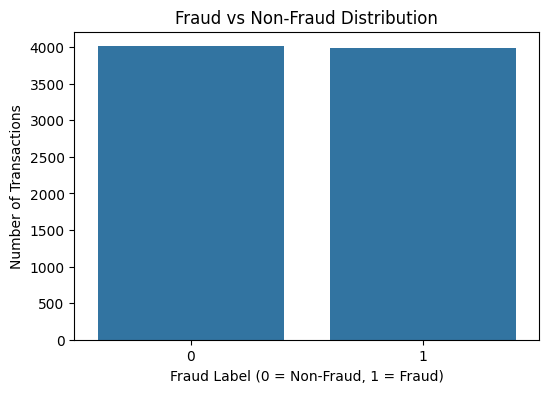

Fraud vs Non-Fraud Counts:
Fraud Flag or Label
0    4011
1    3989
Name: count, dtype: int64


In [ ]:
# Fraud vs Non-Fraud Distribution
fraud_counts = df['Fraud Flag or Label'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=fraud_counts.index,
    y=fraud_counts.values
)
plt.title('Fraud vs Non-Fraud Distribution')
plt.xlabel('Fraud Label (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

print("Fraud vs Non-Fraud Counts:")
print(fraud_counts)


The fraud and non-fraud classes are approximately balanced in the dataset. Therefore, multiple evaluation metrics including accuracy, precision, recall, and F1-score are used to comprehensively assess model performance.

# **Preprocessing Data for Machine Learning**


Preparing the identified features for machine learning by handling missing values, encoding categorical variables using techniques like one-hot encoding and scaling numerical features. The target variable 'Fraud Flag or Label' will be separated from the features.



The first step is to prepare the dataset for machine learning by creating a copy of the original DataFrame, dropping irrelevant columns, and handling missing values in the 'Previous Transactions' column as specified in the instructions. This sets up the data for further preprocessing like encoding and scaling.



In [ ]:
df_processed = df.copy()

# Drop the columns specified in the features_to_drop list
df_processed = df_processed.drop(columns=features_to_drop)

# Fill missing values in 'Previous Transactions'
# Convert to string first in case there are mixed types, then find mode
df_processed['Previous Transactions'] = df_processed['Previous Transactions'].astype(str)
mode_previous_transactions = df_processed['Previous Transactions'].mode()[0]
df_processed['Previous Transactions'] = df_processed['Previous Transactions'].replace('nan', mode_previous_transactions)

print("DataFrame after dropping columns and handling missing values in 'Previous Transactions':")
print(df_processed.head())
print("\nMissing values after processing 'Previous Transactions':")
print(df_processed['Previous Transactions'].isnull().sum())

DataFrame after dropping columns and handling missing values in 'Previous Transactions':
   Transaction Amount  Merchant Category Code (MCC) Transaction Currency  \
0              285.88                          3590                  INR   
1             1777.32                          7277                  EUR   
2             3939.01                          9297                  USD   
3              376.44                          5686                  USD   
4             1687.33                          2940                  INR   

          Card Type  Transaction Response Code  Fraud Flag or Label  \
0        MasterCard                          5                    1   
1  American Express                         12                    1   
2              Visa                          5                    1   
3              Visa                          5                    0   
4        MasterCard                          5                    1   

  Previous Transactions Tra


Now that the missing values have been handled and irrelevant columns have been dropped, the next step is to apply one-hot encoding to the categorical features, scale the numerical features, separate the target variable and then split the data into training and testing sets.



In [ ]:
# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df_processed, columns=categorical_features, drop_first=True, dtype=int)

# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical features
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

# Define features (X) and target (y)
X = df_encoded.drop(columns=target_variable)
y = df_encoded[target_variable]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of X (features after preprocessing):\n", X.head())
print("\nFirst 5 rows of y (target variable):\n", y.head())

Shape of X_train: (5600, 5340)
Shape of X_test: (2400, 5340)
Shape of y_train: (5600,)
Shape of y_test: (2400,)

First 5 rows of X (features after preprocessing):
    Transaction Amount  Merchant Category Code (MCC)_1001  \
0           -1.523278                                  0   
1           -0.495501                                  0   
2            0.994159                                  0   
3           -1.460872                                  0   
4           -0.557514                                  0   

   Merchant Category Code (MCC)_1002  Merchant Category Code (MCC)_1004  \
0                                  0                                  0   
1                                  0                                  0   
2                                  0                                  0   
3                                  0                                  0   
4                                  0                                  0   

   Merchant Category Cod

# **Train and Evaluate Logistic Regression Model**

Implement and train a Logistic Regression model on the preprocessed data. Evaluate the model's performance using classification metrics such as accuracy, precision, recall, F1-score and display a confusion matrix.


**Reasoning**:
Now that the libraries are imported, I will initialize and train the Logistic Regression model, make predictions on the test set, and then calculate and print the evaluation metrics and display the confusion matrix as per the instructions.



Logistic Regression Model Performance:
Accuracy: 0.4942
Precision: 0.4927
Recall: 0.4787
F1-Score: 0.4856


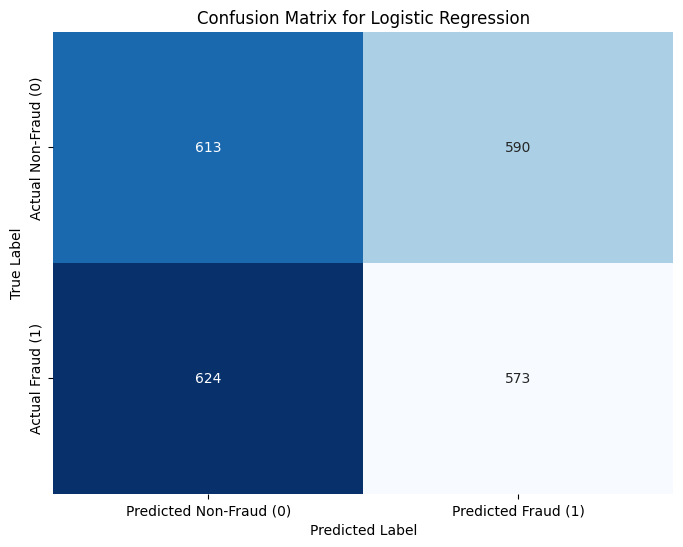

In [ ]:
logistic_model = LogisticRegression(solver='liblinear', random_state=42)
logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)

# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")

# Compute and display the confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Non-Fraud (0)', 'Actual Fraud (1)'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **Train and Evaluate Random Forest Model**

Implement and train a Random Forest Classifier model on the preprocessed data. Evaluate the model's performance using classification metrics such as accuracy, precision, recall, F1-score, and display a confusion matrix.


Random Forest Classifier Model Performance:
Accuracy: 0.4954
Precision: 0.4935
Recall: 0.4444
F1-Score: 0.4677


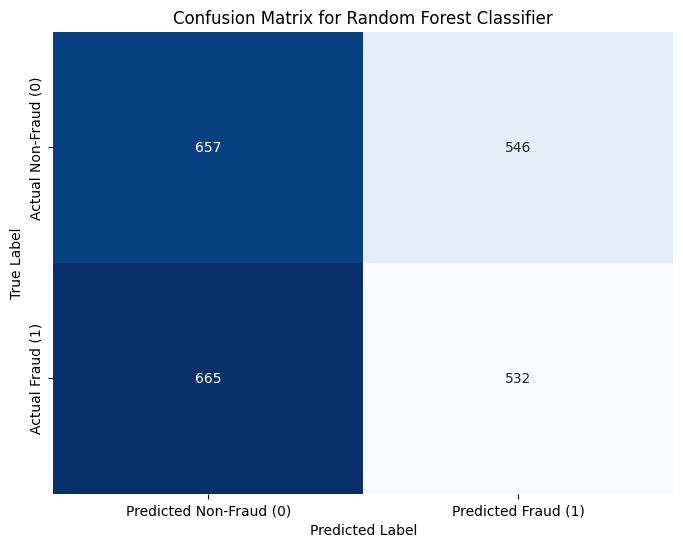

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Compute and display the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Non-Fraud (0)', 'Actual Fraud (1)'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

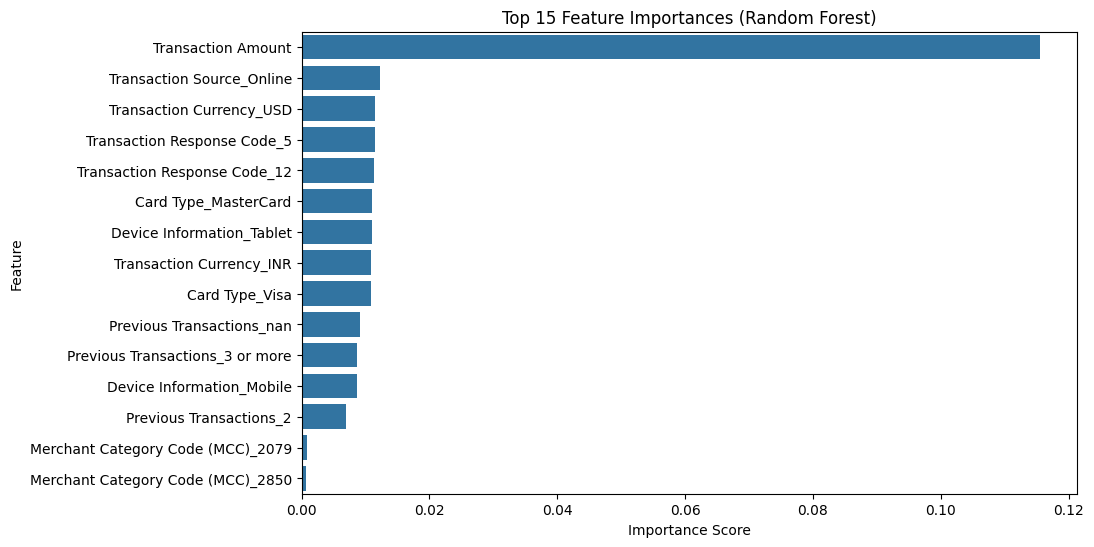

In [ ]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

*   Top Feature: Transaction Amount
*   Other important features: Transaction Source_Online, Transaction Currency_USD, Transaction Response Code_5, Transaction Response Code_12
*   Random Forest seems to emphasize transaction amount and transaction metadata more than card type or previous transactions.
*   Feature importance scores are more spread out, with the top feature (Transaction Amount) being significantly higher than others (~0.11).

# **Train and Evaluate XGBoost Model**

Implement and train a Gradient Boosting Classifier model on the preprocessed data. Evaluate the model's performance using classification metrics such as accuracy, precision, recall, F1-score and display a confusion matrix.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:13:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Model Performance:
Accuracy: 0.4967
Precision: 0.4955
Recall: 0.5004
F1-Score: 0.4979


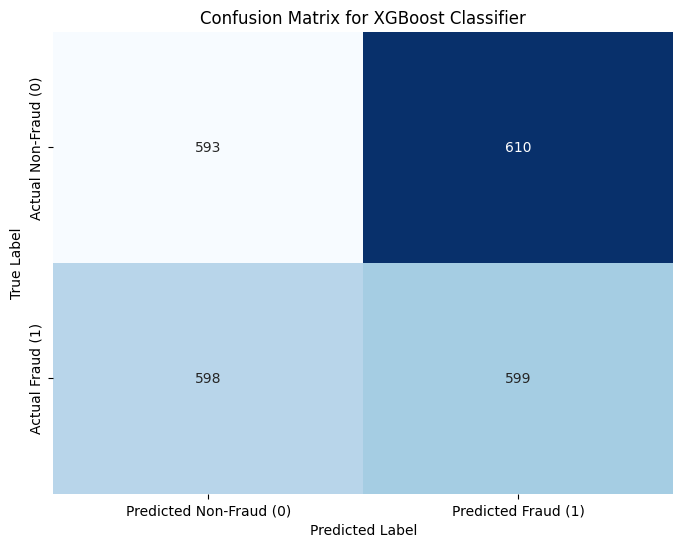

In [ ]:
# Initialize and train the XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Classifier Model Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
# Compute and display the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Non-Fraud (0)', 'Actual Fraud (1)'])
plt.title('Confusion Matrix for XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

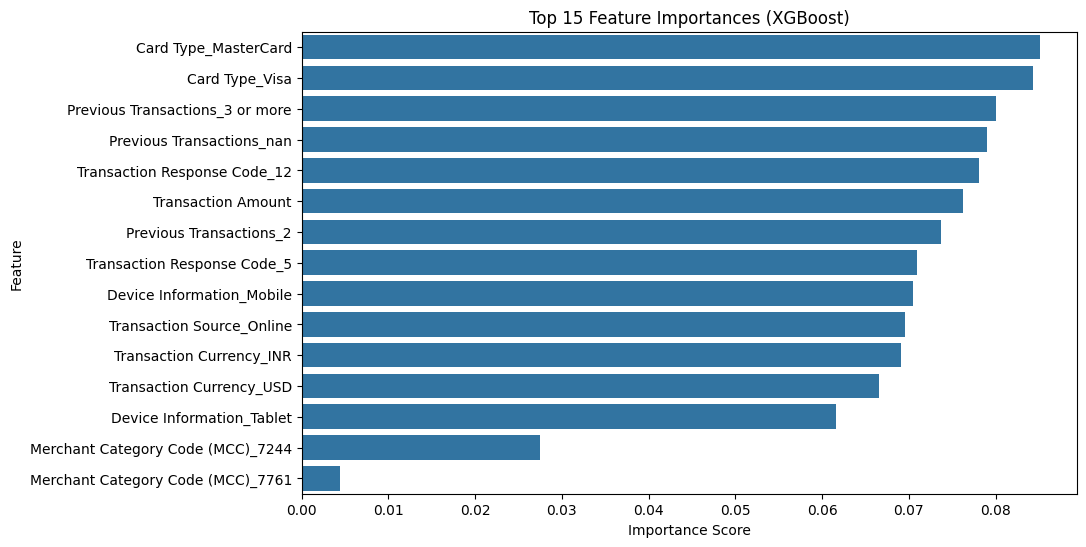

In [ ]:
# Feature Importance from XGBoost
importances_xgb = xgb_model.feature_importances_
feature_names = X.columns

xgb_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=xgb_feature_importance_df
)
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

*   Top Feature: Card Type_MasterCard and Card Type_Visa
*   Other important features: Previous Transactions_3 or more, Previous Transactions_nan, Transaction Response Code_12, Transaction Amount
*   XGBoost seems to highlight card type and previous transaction history more than transaction amount.
*   The importance distribution is a bit more balanced among the top features (~0.08–0.07 for top features) compared to Random Forest.




The Random Forest feature importance plot highlights Transaction Amount as the most influential feature, followed by transaction metadata such as source and currency. In contrast, the XGBoost model places greater
emphasis on Card Type and previous transaction history, with transaction amount playing a secondary role. Overall, Random Forest tends to prioritize numeric transaction values, while XGBoost captures more subtle patterns in categorical features and user behavior, offering a more balanced distribution of top feature importance.

# **Summary:**

**Dataset Description:**
The dataset contains 8000 rows and 20 columns, with one `float64` column (`Transaction Amount`), three `int64` columns, and sixteen `object` columns. There are missing values in `Previous Transactions` (2043 entries) and `User Account Information` (4010 entries). Numerical features like `Transaction Amount` range from \$1.09 to \$4996.70. The target variable, `Fraud Flag or Label`, shows a nearly balanced distribution between fraudulent and non-fraudulent transactions, with a mean of approximately 0.4986.

**Selected Features for Machine Learning:**
For machine learning, 'Transaction Amount' was identified as the key numerical feature. Categorical features selected include 'Merchant Category Code (MCC)', 'Transaction Currency', 'Card Type', 'Transaction Response Code', 'Previous Transactions', 'Transaction Source', and 'Device Information'. Features like 'Transaction Date and Time', 'Cardholder Name', 'Card Number (Hashed or Encrypted)', 'Merchant Name', 'Transaction Location (City or ZIP Code)', 'Card Expiration Date', 'CVV Code (Hashed or Encrypted)', 'Transaction ID', 'IP Address', 'User Account Information', and 'Transaction Notes' were identified for dropping or requiring advanced preprocessing due to being identifiers, having high cardinality, being Personally Identifiable Information (PII), or requiring specialized techniques like Natural Language Processing (NLP) or date/time feature engineering.

**Comparison of Model Performance:**
The performance metrics for the three models are as follows:

| Metric    | Logistic Regression | Random Forest | XGBoost |
|-----------|---------------------|---------------|-------------------|
| Accuracy  | 0.4942              | 0.4954        | 0.4967            |
| Precision | 0.4927              | 0.4935        | 0.4955            |
| Recall    | 0.4787              | 0.4444        | 0.5004            |
| F1-Score  | 0.4856              | 0.4677        | 0.4979            |

All models exhibited low overall performance across the evaluated metrics.

**Most Suitable Model for Fraud Detection:**
For fraud detection, Recall is often the most critical metric as it measures the model's ability to identify all actual fraudulent transactions, thereby minimizing undetected fraud (false negatives). In this context, the XGBoost model showed the highest Recall score at 0.5004, outperforming Logistic Regression (0.4787) and Random Forest (0.4444). Therefore, based on the emphasis on minimizing false negatives, XGBoost might be considered the most suitable among the three for this specific fraud detection task, despite its overall low performance.

### Data Analysis Key Findings

*   The dataset comprises 8000 rows and 20 columns, with `Transaction Amount` being the only `float64` numerical feature.
*   Significant missing values were found in `Previous Transactions` (2043 entries) and `User Account Information` (4010 entries).
*   The `Fraud Flag or Label` target variable is nearly balanced, with approximately 49.86\% fraudulent transactions.
*   11 columns were either dropped or earmarked for advanced preprocessing due to reasons such as high cardinality, unique identifiers, PII, or requiring specialized feature engineering.
*   Missing values in 'Previous Transactions' were imputed using the mode. Categorical features were one-hot encoded, and numerical features were scaled using `StandardScaler`.
*   All three machine learning models (Logistic Regression, Random Forest, XGBoost) yielded low performance metrics. Accuracy scores hovered around 0.49, Precision around 0.49, Recall between 0.44 and 0.50, and F1-Scores between 0.46 and 0.49.



